In [1]:
# Load the dataset and do a quick sanity check
import pandas as pd

file_path = "data.csv"
df = pd.read_csv(file_path, encoding="ascii")

print(df.head())
print(df.shape)

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

In [2]:
# Identify target column, missingness, and basic class balance
import numpy as np

na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(15))

# Heuristic: target likely a low-cardinality column; pick the column with the fewest unique values (but >1)
unique_counts = df.nunique(dropna=True).sort_values()
print(unique_counts.head(25))

candidate_targets = unique_counts[(unique_counts > 1) & (unique_counts <= 10)].index.tolist()
print(candidate_targets[:30])

MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
minHBint8          0
MATS3e             0
MATS3c             0
minHBint2          0
MATS3m             0
minHBint6          0
minHBint7          0
minHBint4          0
MATS3i             0
VR3_Dt             0
dtype: int64
C2SP1               2
khs.sBr             2
khs.dCH2            2
LipinskiFailures    2
ndNH                2
maxssssNp           2
ETA_dAlpha_A        2
khs.aaS             2
minHtCH             2
SHdCH2              2
minssssNp           2
naaS                2
nssssNp             2
maxdCH2             2
nsBr                2
mindCH2             2
SsBr                2
maxHdCH2            2
maxdS               2
nHdNH               2
SssssNp             2
khs.tCH             2
nBr                 2
minHdCH2            2
SHtCH               2
dtype: int64
['C2SP1', 'khs.sBr', 'khs.dCH2', 'LipinskiFailures', 'ndNH', 'maxssssNp', 'ETA_dAlpha_A', 'khs.aaS', 'minHtCH

In [3]:
# Data cleaning + preprocessing setup, and quick EDA on the target balance
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, roc_auc_score

# Assume target is the 'Class' column (looks like binary)
target_col = "Class"

y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

# Coerce to numeric where possible (many descriptors should already be numeric)
X = X.apply(pd.to_numeric, errors="coerce")

print(y.value_counts(dropna=False))

# Basic missingness check after coercion
missing_frac = X.isna().mean().sort_values(ascending=False)
print(missing_frac.head(15))

# Drop columns that are almost entirely missing or constant
const_mask = X.nunique(dropna=True) <= 1
high_missing_mask = missing_frac > 0.5

cols_to_drop = X.columns[const_mask | high_missing_mask].tolist()
print(len(cols_to_drop))

X_clean = X.drop(columns=cols_to_drop)
print(X_clean.shape)

Class
NonToxic    115
Toxic        56
Name: count, dtype: int64
MATS3v             0.0
nHBint10           0.0
MATS3s             0.0
MATS3p             0.0
nHBDon_Lipinski    0.0
minHBint8          0.0
MATS3e             0.0
MATS3c             0.0
minHBint2          0.0
MATS3m             0.0
minHBint6          0.0
minHBint7          0.0
minHBint4          0.0
MATS3i             0.0
VR3_Dt             0.0
dtype: float64
0
(171, 1203)


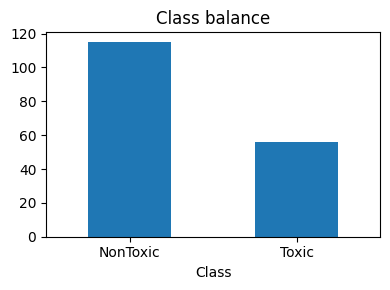

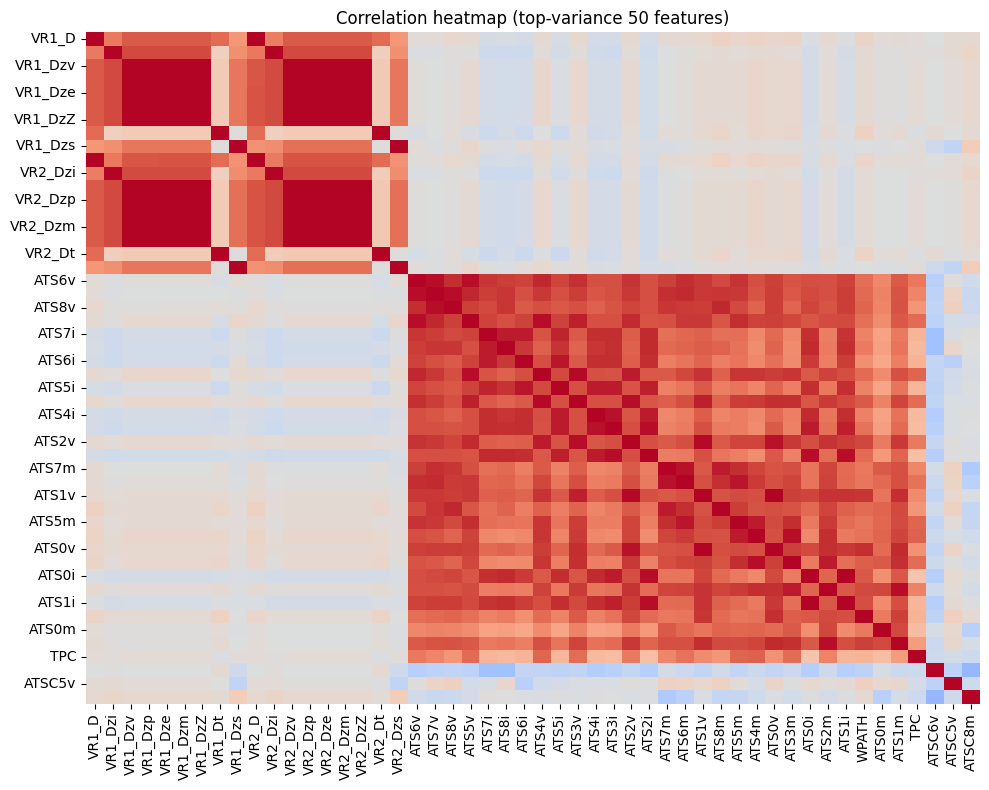

In [4]:
# EDA visuals: class balance and a quick correlation heatmap on a subset of features
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = y.value_counts()
plt.figure(figsize=(4,3))
class_counts.plot(kind="bar")
plt.title("Class balance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation on top-50 variance features (to keep it readable)
feat_var = X_clean.var(numeric_only=True).sort_values(ascending=False)
top_var_cols = feat_var.head(50).index.tolist()

corr_mat = X_clean[top_var_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_mat, cmap="coolwarm", center=0, cbar=False)
plt.title("Correlation heatmap (top-variance 50 features)")
plt.tight_layout()
plt.show()

      label  MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8
0  NonToxic  0.0908         0  0.0075  0.0173                0        0.0
1  NonToxic  0.0213         0  0.1144 -0.0410                0        0.0
2  NonToxic  0.0018         0 -0.0156 -0.0765                2        0.0
3  NonToxic -0.0251         0 -0.0064 -0.0894                3        0.0
4  NonToxic  0.0135         0  0.0424 -0.0353                0        0.0


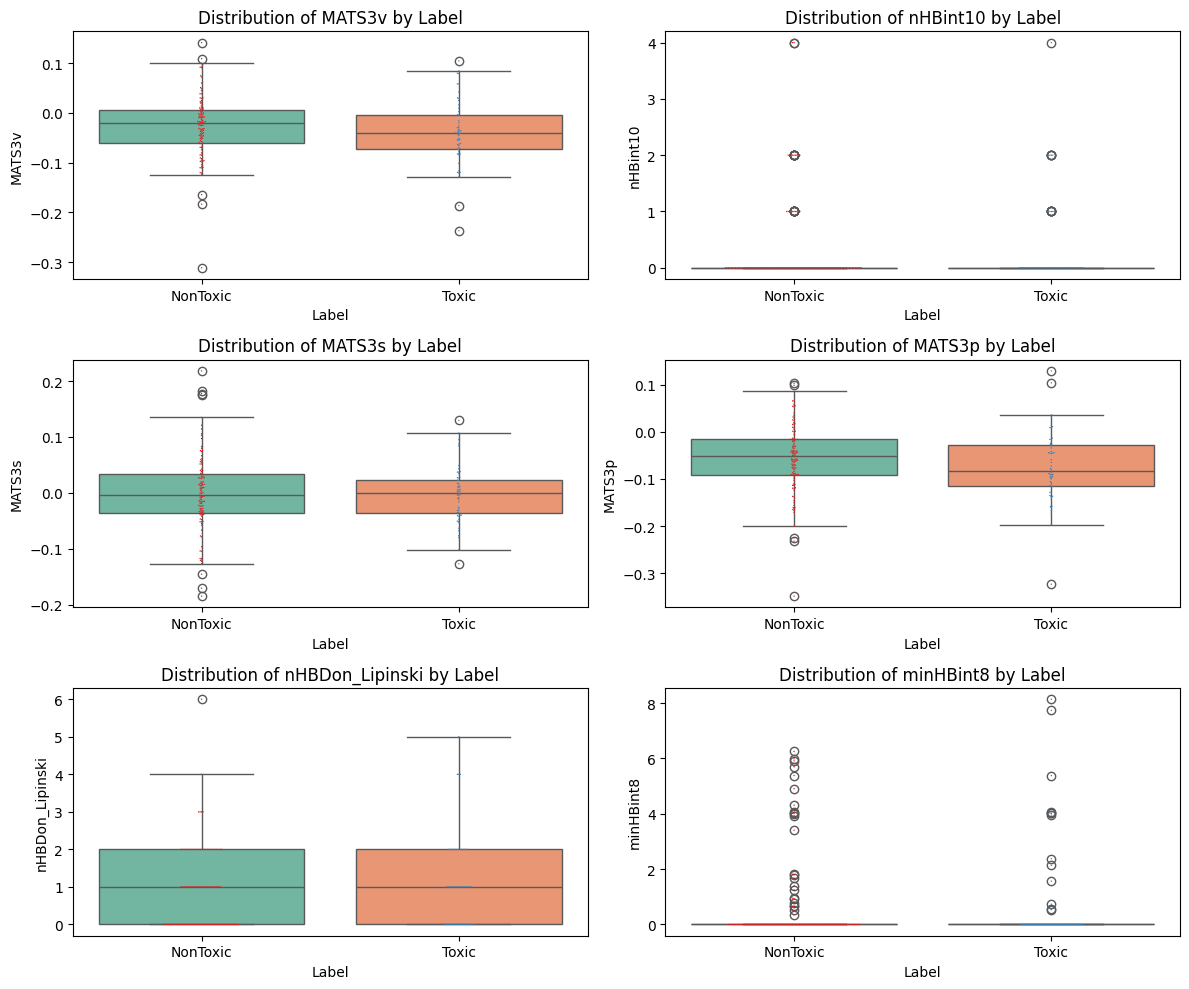

In [9]:

# Create the box+swarm plots for the first 6 features in final_df (or fall back to a reasonable dataframe)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pick the dataframe to use
if "final_df" in globals():
    plot_df = final_df.copy()
else:
    # Fallback: build a plotting dataframe from the cleaned feature matrix and label
    plot_df = X_clean.copy()
    plot_df["label"] = pd.Series(y_bin).map({0: "NonToxic", 1: "Toxic"}).values

# Ensure label column exists and is named as expected
if "label" not in plot_df.columns:
    if "Class" in plot_df.columns:
        plot_df = plot_df.rename(columns={"Class": "label"})
    elif "y" in plot_df.columns:
        plot_df = plot_df.rename(columns={"y": "label"})

# Keep only numeric feature columns for plotting
feat_cols = [c for c in plot_df.columns if c != "label" and pd.api.types.is_numeric_dtype(plot_df[c])]
feat_cols = feat_cols[:6]

print(plot_df[["label"] + feat_cols].head())

plt.figure(figsize=(12, 10))
for idx, feat_name in enumerate(feat_cols, 1):
    plt.subplot(3, 2, idx)
    sns.boxplot(
        data=plot_df,
        x="label",
        y=feat_name,
        hue="label",
        palette="Set2",
        legend=False
    )
    sns.swarmplot(
        data=plot_df,
        x="label",
        y=feat_name,
        hue="label",
        palette="Set1",
        legend=False,
        size=1.0
    )
    plt.title("Distribution of " + str(feat_name) + " by Label")
    plt.xlabel("Label")
    plt.ylabel(str(feat_name))

plt.tight_layout()
plt.show()

                    f1  precision    recall   roc_auc
RandomForest  0.179487   0.318182  0.125000  0.528649
HistGB        0.133333   0.176471  0.107143  0.485404
ExtraTrees    0.144578   0.222222  0.107143  0.479969
LogReg        0.271186   0.258065  0.285714  0.421118


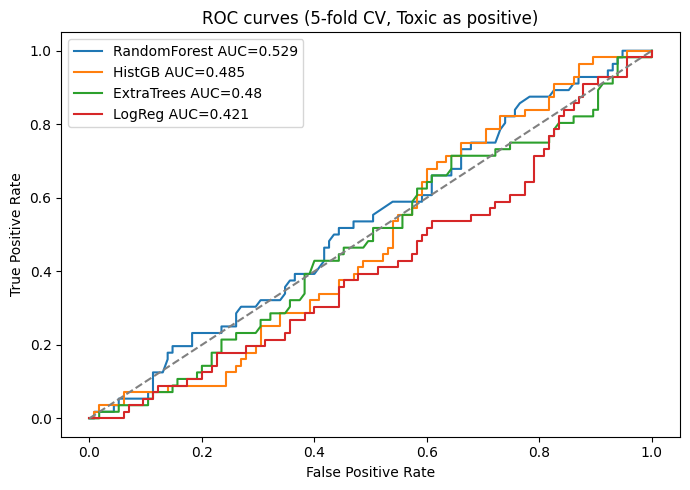

In [5]:
# Feature selection with Mutual Information + CV with imbalance handling, then evaluate multiple ensemble models
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, RocCurveDisplay, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# Encode y to 0/1 with Toxic as positive
y_bin = (y.astype(str) == "Toxic").astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Common preprocessing + MI feature selection
k_features = min(100, X_clean.shape[1])
preprocess_and_select = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("select", SelectKBest(score_func=mutual_info_classif, k=k_features))
])

# Models (all sklearn; handle imbalance via class_weight where supported)
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"),
    "RandomForest": RandomForestClassifier(n_estimators=600, random_state=42, class_weight="balanced_subsample"),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=800, random_state=42, class_weight="balanced_subsample"),
    "HistGB": HistGradientBoostingClassifier(random_state=42)
}

# Evaluate each model with cross-validated predictions
model_reports = {}
roc_data = {}

for model_name, model_obj in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocess_and_select),
        ("clf", model_obj)
    ])

    # Probabilities for ROC when possible
    if hasattr(model_obj, "predict_proba"):
        y_proba = cross_val_predict(pipe, X_clean, y_bin, cv=cv, method="predict_proba")[:, 1]
    else:
        # fallback for models without predict_proba
        y_proba = cross_val_predict(pipe, X_clean, y_bin, cv=cv, method="decision_function")

    y_pred = (y_proba >= 0.5).astype(int)

    rep = {
        "f1": f1_score(y_bin, y_pred),
        "precision": precision_score(y_bin, y_pred, zero_division=0),
        "recall": recall_score(y_bin, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_bin, y_proba)
    }
    model_reports[model_name] = rep
    fpr_vals, tpr_vals, _ = roc_curve(y_bin, y_proba)
    roc_data[model_name] = (fpr_vals, tpr_vals)

# Put results in a table
report_df = pd.DataFrame(model_reports).T.sort_values("roc_auc", ascending=False)
print(report_df)

# Soft-voting ensemble of best 3 proba models by ROC AUC (exclude HistGB if it lacks predict_proba, but it does have)
sorted_models = report_df.index.tolist()

# Draw ROC curves
plt.figure(figsize=(7,5))
for model_name in sorted_models:
    fpr_vals, tpr_vals = roc_data[model_name]
    auc_val = auc(fpr_vals, tpr_vals)
    plt.plot(fpr_vals, tpr_vals, label=model_name + " AUC=" + str(round(auc_val, 3)))

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (5-fold CV, Toxic as positive)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Feature selection size
k_features = min(200, X_clean.shape[1])

# Preprocessing pipeline
prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(mutual_info_classif, k=k_features))
])

# Models
models = {
    "ExtraTrees": ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "HistGB": HistGradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    y_probs = np.zeros(len(y_bin))

    for train_idx, test_idx in cv.split(X_clean, y_bin):

        X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
        y_train = y_bin[train_idx]

        pipe = Pipeline([
            ("prep", prep),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        y_probs[test_idx] = pipe.predict_proba(X_test)[:,1]

    # simple threshold tuning
    thresholds = np.linspace(0.1, 0.9, 50)
    best_f1 = 0
    best_thr = 0.5

    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        score = f1_score(y_bin, preds)

        if score > best_f1:
            best_f1 = score
            best_thr = t

    final_preds = (y_probs >= best_thr).astype(int)

    results.append({
        "model": name,
        "threshold": best_thr,
        "F1": f1_score(y_bin, final_preds),
        "precision": precision_score(y_bin, final_preds),
        "recall": recall_score(y_bin, final_preds),
        "ROC_AUC": roc_auc_score(y_bin, y_probs)
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

print(results_df)

          model  threshold        F1  precision    recall   ROC_AUC
1  RandomForest    0.14898  0.504950   0.349315  0.910714  0.518789
0    ExtraTrees    0.10000  0.492891   0.335484  0.928571  0.489053
3        HistGB    0.10000  0.402778   0.329545  0.517857  0.481211
2        LogReg    0.10000  0.409357   0.304348  0.625000  0.444099


In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_features = min(200, X_clean.shape[1])

models = {
    "ExtraTrees": ExtraTreesClassifier(n_estimators=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42),
    "LogReg": LogisticRegression(max_iter=5000),
    "HistGB": HistGradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    y_probs = np.zeros(len(y_bin))

    for train_idx, test_idx in cv.split(X_clean, y_bin):

        X_train = X_clean.iloc[train_idx]
        X_test = X_clean.iloc[test_idx]
        y_train = y_bin[train_idx]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif, k=k_features)),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        y_probs[test_idx] = pipe.predict_proba(X_test)[:,1]

    # Threshold tuning
    thresholds = np.linspace(0.1, 0.9, 50)
    best_thr = 0.5
    best_f1 = 0

    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        score = f1_score(y_bin, preds)

        if score > best_f1:
            best_f1 = score
            best_thr = t

    final_preds = (y_probs >= best_thr).astype(int)

    results.append({
        "model": name,
        "threshold": best_thr,
        "F1": f1_score(y_bin, final_preds),
        "precision": precision_score(y_bin, final_preds),
        "recall": recall_score(y_bin, final_preds),
        "ROC_AUC": roc_auc_score(y_bin, y_probs)
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

print(results_df)

          model  threshold        F1  precision    recall   ROC_AUC
1  RandomForest   0.165306  0.507177   0.346405  0.946429  0.509705
0    ExtraTrees   0.148980  0.490196   0.337838  0.892857  0.496273
3        HistGB   0.100000  0.402778   0.329545  0.517857  0.478571
2        LogReg   0.100000  0.348387   0.272727  0.482143  0.427950


Best parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 200}
Best CV ROC-AUC: 0.571111111111111
              precision    recall  f1-score   support

           0       0.72      0.88      0.79        24
           1       0.50      0.27      0.35        11

    accuracy                           0.69        35
   macro avg       0.61      0.57      0.57        35
weighted avg       0.65      0.69      0.65        35

Test ROC-AUC: 0.6666666666666667


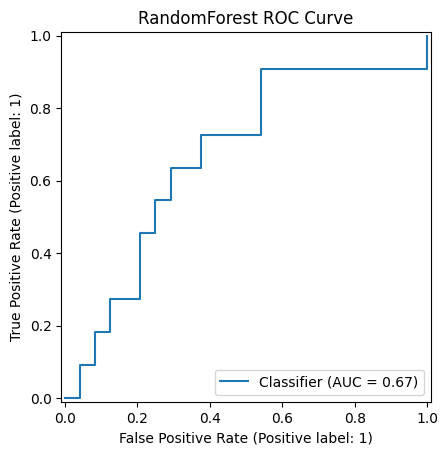

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

# FIX 1: import SMOTE
from imblearn.over_sampling import SMOTE

# FIX 2: use imblearn pipeline
from imblearn.pipeline import Pipeline


# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

k_features = min(100, X_tr.shape[1])

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(mutual_info_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "rf__n_estimators": [200, 400],
    "rf__max_depth": [None, 16],
    "rf__min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gs = GridSearchCV(
    rf_pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

gs.fit(X_tr, y_tr)

print("Best parameters:", gs.best_params_)
print("Best CV ROC-AUC:", gs.best_score_)

best_model = gs.best_estimator_

y_pred = best_model.predict(X_te)
y_proba = best_model.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred, zero_division=0))
print("Test ROC-AUC:", roc_auc_score(y_te, y_proba))

RocCurveDisplay.from_predictions(y_te, y_proba)
plt.title("RandomForest ROC Curve")
plt.show()